# Converters

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
working_directory = "/Users/kemalinecik/git_nosync/sctram"

In [3]:
import sys
sys.path.append(working_directory)

import logging
import os
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
from scipy.stats import pearsonr, spearmanr

sc.settings.verbosity = 3

In [4]:
from sctram.evaluate._converters._adjacency2pseudotime import LabelAdjacencyPseudotimeConverter
from sctram.evaluate._converters._pseudotime2adjacency import PseudotimeLabelAdjacencyConverter
from sctram.evaluate._converters._diffmap2adjacency import DiffmapAdjacencyConverter

from sctram.generate.real import sc_datasets_paul15

from sctram.infer._paga import PAGAInference
from sctram.infer._dpt import DPTInference
from sctram.infer._diffmap import DiffmapEmbedding

In [5]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, 'rb') as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

## Dataset, DPT, PAGA, Diffmap

In [6]:
dataset_dir = "/Users/kemalinecik/git_nosync/sctram/__temp__/data"
adata = sc_datasets_paul15(dataset_dir=dataset_dir)
sc.pp.recipe_zheng17(adata)
sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=90, n_pcs=20)
sc.tl.louvain(adata, resolution=1.0)
sc.tl.umap(adata)
sc.tl.diffmap(adata)

running recipe zheng17
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)
running Louvain clustering
    using the "louvain" package of Traag (2017)
    finished: found 6 clusters and added
    'louvain', the cluster labels (adata.obs, categorical) (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:05)
computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.99456316 0.97238886 0.9640743  0.95089775 0.94141906
     0.9046889  0.9008314  0.895430

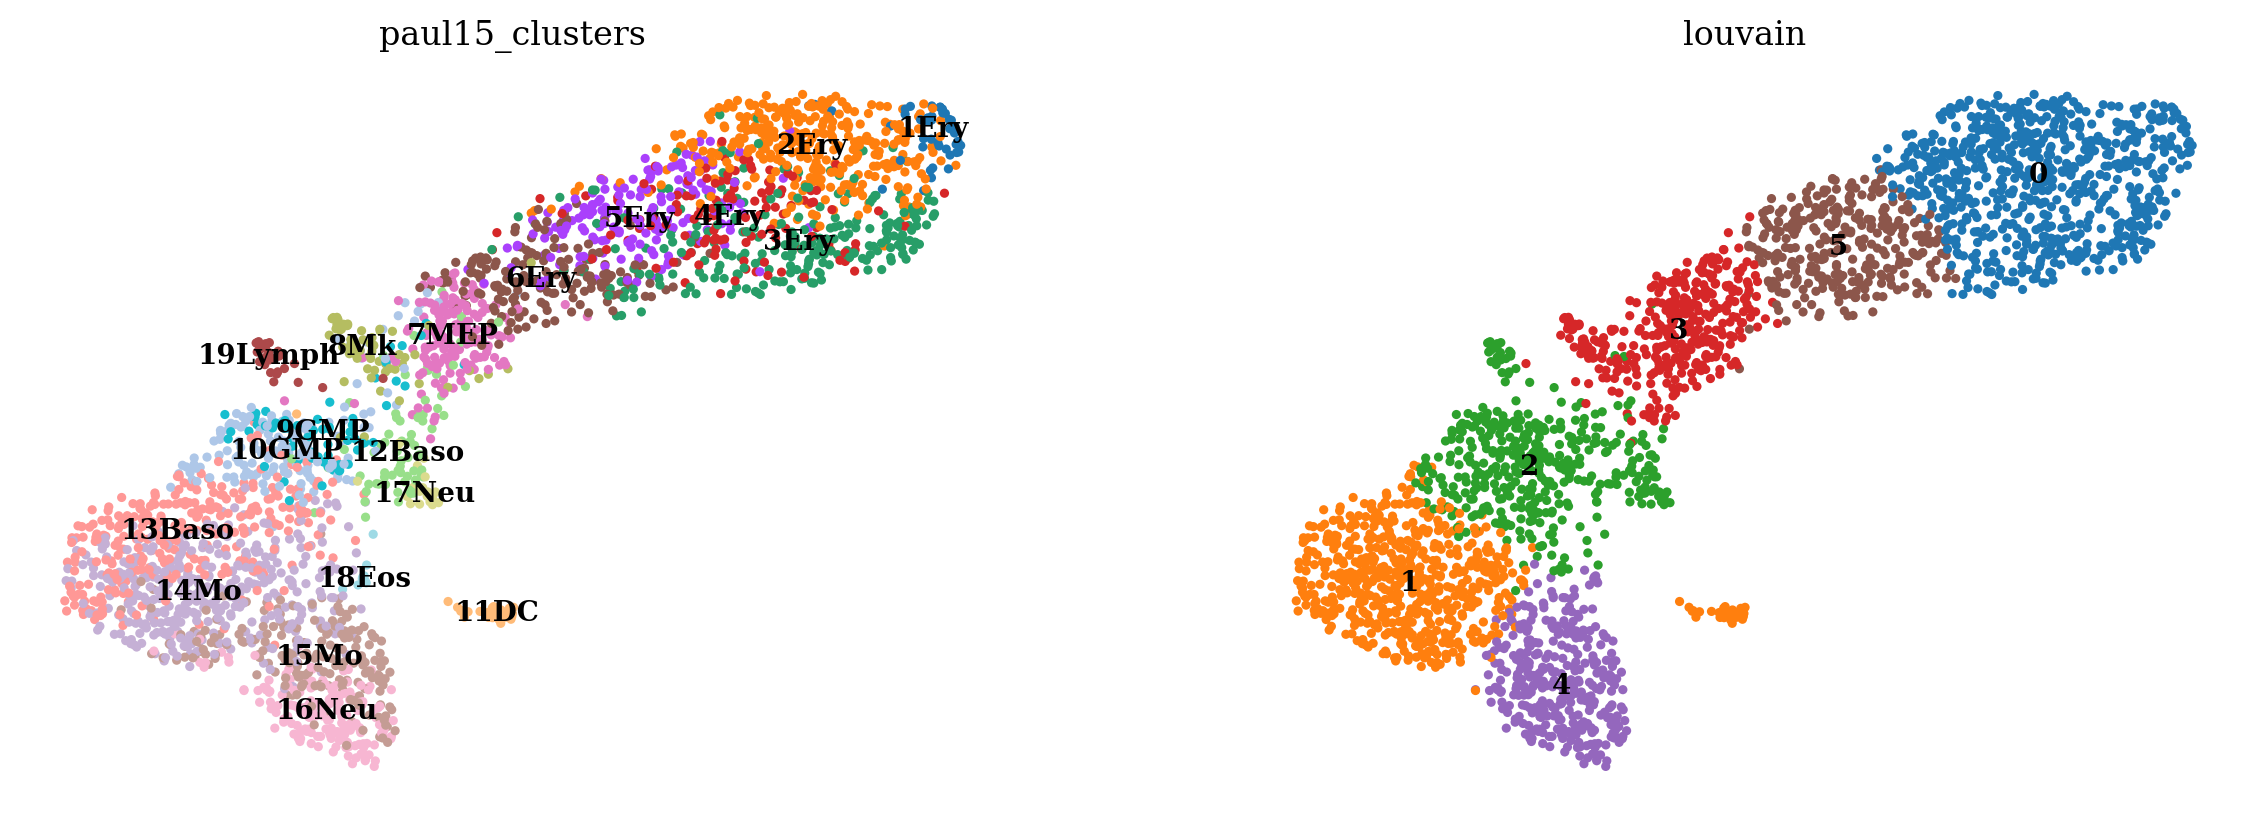

In [7]:
sc.pl.umap(adata, color=["paul15_clusters", "louvain"], frameon=False, legend_loc="on data")

In [8]:
print('categories:\n', adata.obs["paul15_clusters"].cat.categories)
root_label = adata.obs["paul15_clusters"].iloc[adata.uns['iroot']]
print('\niroot label:\n', root_label)
print('\nadata:\n', adata)

categories:
 Index(['1Ery', '2Ery', '3Ery', '4Ery', '5Ery', '6Ery', '7MEP', '8Mk', '9GMP',
       '10GMP', '11DC', '12Baso', '13Baso', '14Mo', '15Mo', '16Neu', '17Neu',
       '18Eos', '19Lymph'],
      dtype='object')

iroot label:
 8Mk

adata:
 AnnData object with n_obs × n_vars = 2730 × 999
    obs: 'paul15_clusters', 'n_counts_all', 'louvain'
    var: 'n_counts', 'mean', 'std'
    uns: 'iroot', 'log1p', 'pca', 'neighbors', 'louvain', 'umap', 'diffmap_evals', 'paul15_clusters_colors', 'louvain_colors'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


In [9]:
paga_inference = PAGAInference(
    random_state=42, 
    neighbors_params={"n_neighbors": 60}, 
    adata=adata, 
    labels=adata.obs["paul15_clusters"]
)
paga_inference.calculate()
adjacency_matrix = paga_inference.get_result("adjacency")
adjacency_matrix_labels = paga_inference.get_result("labels")

INFO:PAGAInference:Starting PAGAInference trajectory inference.
INFO:PAGAInference:Performing trajectory inference.
INFO:PAGAInference:Using precomputed neighbors from AnnData.


running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


INFO:PAGAInference:Trajectory inference completed successfully.


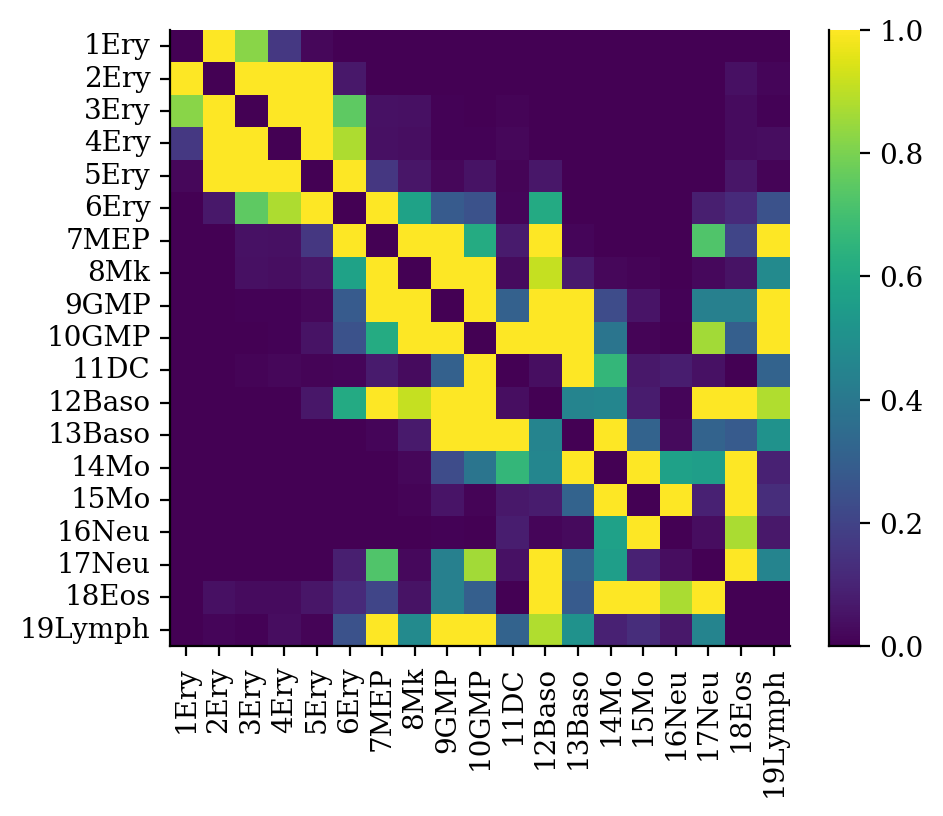

In [10]:
adjacency_matrix_df = pd.DataFrame(adjacency_matrix, columns=adjacency_matrix_labels, index=adjacency_matrix_labels)
plt.figure(figsize=(5, 4))
sns.heatmap(adjacency_matrix_df, cmap='viridis')
sns.despine()
plt.show()

--> added 'pos', the PAGA positions (adata.uns['paga'])


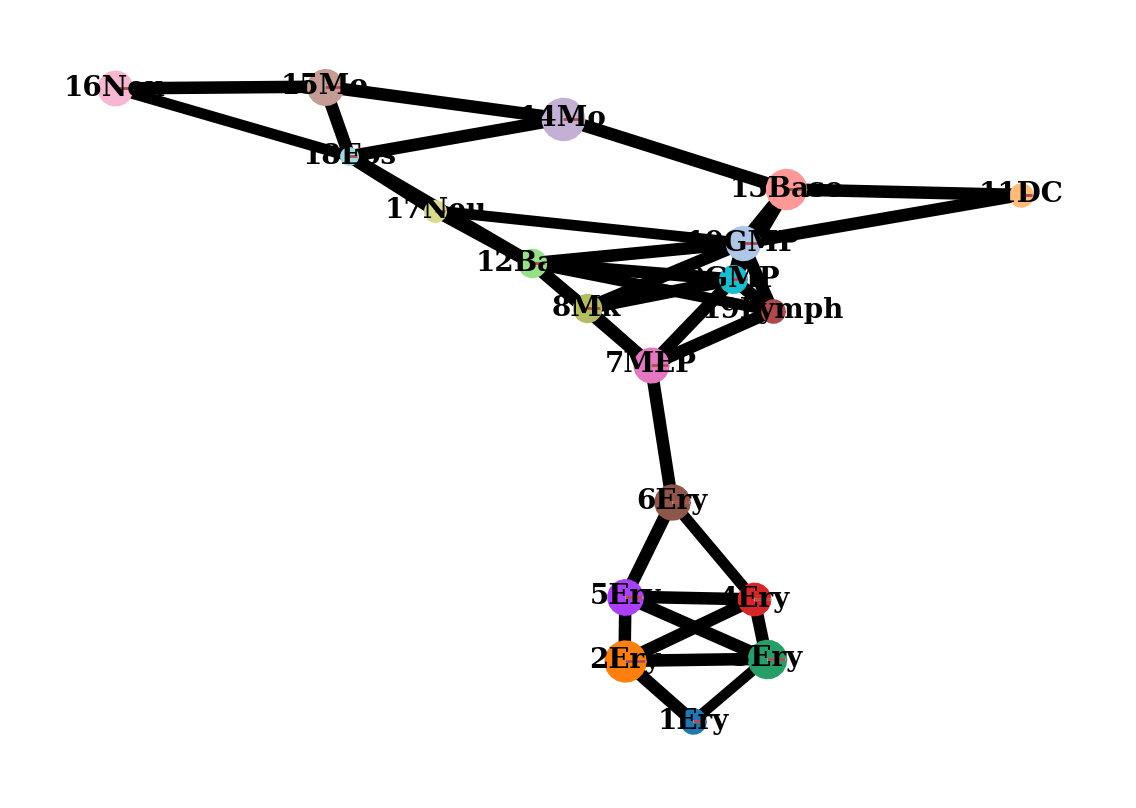

In [11]:
sc.pl.paga(paga_inference.get_result("anndata"), color=["paul15_clusters"], frameon=False, threshold=0.8, edge_width_scale=0.6)

In [12]:
iroot_params = int(adata.uns['iroot'])
dpt_inference = DPTInference(
    random_state=42, 
    neighbors_params={"n_neighbors": 90},
    iroot_params=iroot_params,
    adata=adata, 
    labels=adata.obs["paul15_clusters"]
)
dpt_inference.calculate()
pseudotime = dpt_inference.get_result("vector")

INFO:DPTInference:Starting DPTInference trajectory inference.
INFO:DPTInference:Performing trajectory inference.
INFO:DPTInference:Using precomputed neighbors from AnnData.
INFO:DPTInference:Diffusion Map is already calculated.
INFO:DPTInference:Root set to cell index 840 based on provided index.
INFO:DPTInference:Performing DPT trajectory calculation.


computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)


INFO:DPTInference:Trajectory inference completed successfully.


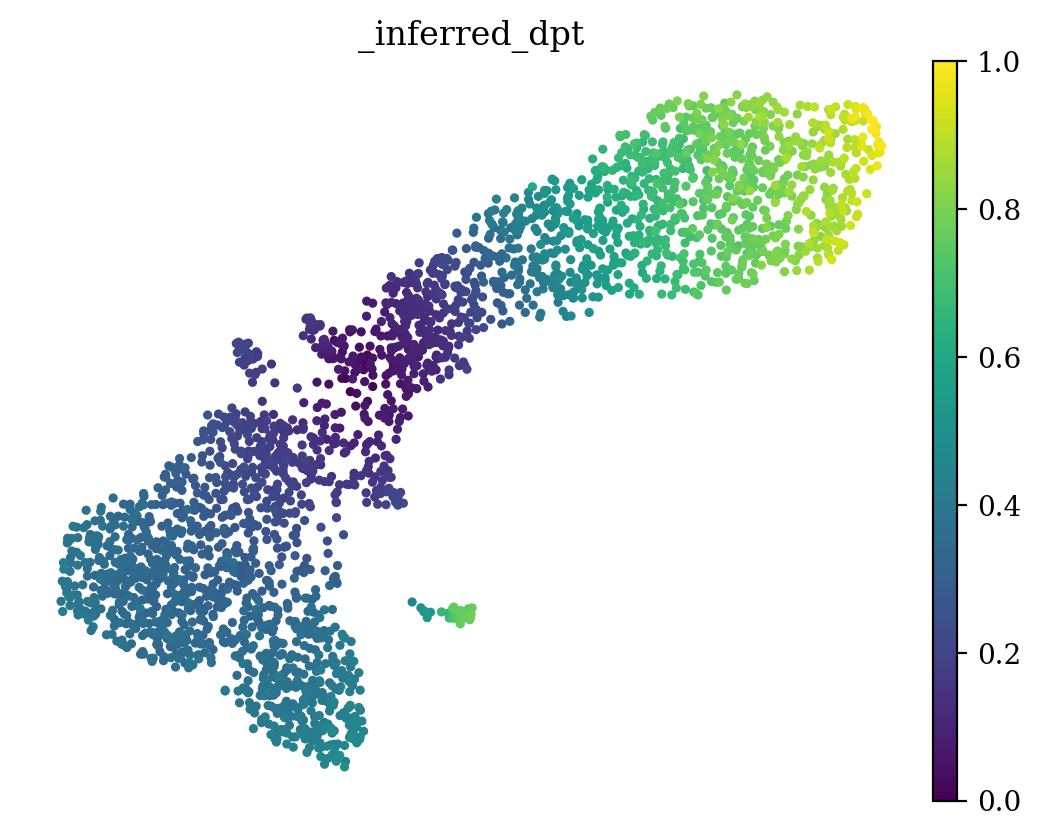

In [13]:
adata.obs["_inferred_dpt"] = pseudotime
sc.pl.umap(adata, color=["_inferred_dpt"], frameon=False)

In [14]:
embedding_object = DiffmapEmbedding(
    random_state=42,
    neighbors_params={"n_neighbors": 90},
    diffmap_params=None, 
    adata=adata, 
    labels=adata.obs["paul15_clusters"]
)
embedding_object.calculate()
diffmap = embedding_object.get_result("diffmap")

INFO:DiffmapEmbedding:Starting DiffmapEmbedding embedding calculation.
INFO:DiffmapEmbedding:Performing embedding calculation.
INFO:DiffmapEmbedding:Using precomputed neighbors from AnnData.
INFO:DiffmapEmbedding:Diffusion Map is already calculated.
INFO:DiffmapEmbedding:Embedding calculation completed successfully.


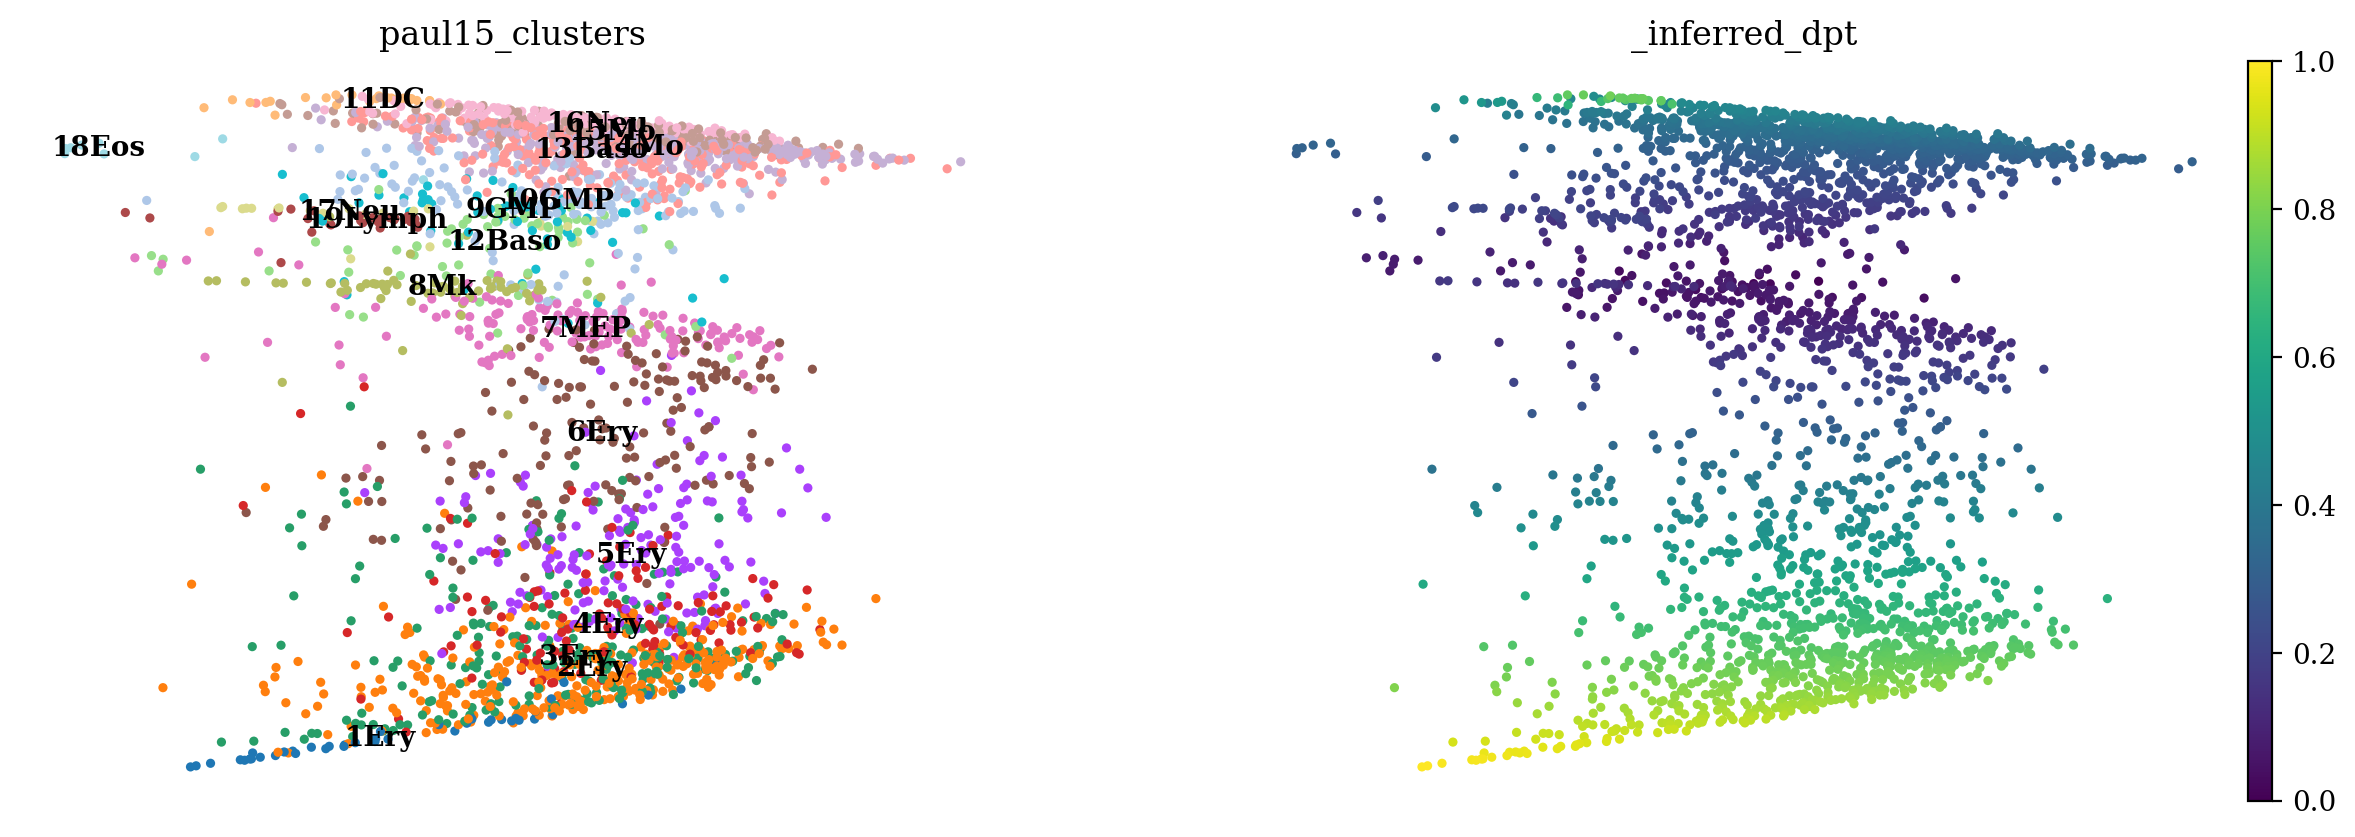

In [15]:
sc.pl.diffmap(embedding_object.get_result("anndata"), color=["paul15_clusters", "_inferred_dpt"], frameon=False, legend_loc="on data")

## Converter Adjacency to Pseutotime

In [16]:
root_index = np.where(adjacency_matrix_labels == root_label)[0][0]
cell_labels = np.array(list(adata.obs["paul15_clusters"]))
converter = LabelAdjacencyPseudotimeConverter(
    adjacency_matrix, 
    label_adjacency_matrix_labels=adjacency_matrix_labels,
    cell_labels=cell_labels
)

In [17]:
def check_conversion(cell_pseudotime, label_pseudotime, plot_coversion=False, plot_umap=False):
    print("Cell Pseudotime:")

    if plot_coversion:
        df_plot = pd.DataFrame({
            "inferred": pseudotime,
            "converted": cell_pseudotime,
            "labels": cell_labels})
        plt.figure(figsize=(3,3))
        sns.scatterplot(data=df_plot, x="inferred", y="converted", hue="labels", legend=False, linewidth=0)
        sns.despine()
        plt.show()

    print("spearman:", spearmanr(pseudotime, cell_pseudotime))
    print("pearson:", pearsonr(pseudotime, cell_pseudotime))

    print("\nLabel Pseudotime:")

    mean_pseudotime = np.array([pseudotime[cell_labels == cat].mean() for cat in adjacency_matrix_labels])

    if plot_coversion:
        df_plot = pd.DataFrame({
            "inferred": mean_pseudotime,
            "converted": label_pseudotime,
            "labels": adjacency_matrix_labels})
        plt.figure(figsize=(3,3))
        sns.scatterplot(data=df_plot, x="inferred", y="converted", hue="labels", legend=False, linewidth=0)
        sns.despine()
        plt.show()

    print("spearman:", spearmanr(mean_pseudotime, label_pseudotime))
    print("pearson:", pearsonr(mean_pseudotime, label_pseudotime))
    
    if plot_umap:
        adata.obs["_inferred_dpt"] = cell_pseudotime
        _, ax = plt.subplots(figsize=(5, 3))
        sc.pl.umap(adata, color=["_inferred_dpt"], frameon=False, show=False, ax=ax, size=15)
        plt.show()
    
        _, ax = plt.subplots(figsize=(5, 3))
        sc.pl.diffmap(adata, color=["_inferred_dpt"], frameon=False, show=False, ax=ax, size=15)
        plt.show()

In [18]:
label_pseudotime = converter.get_label_pseudotime(method="shortest_path", root_label=root_index)
cell_pseudotime = converter.get_cell_pseudotime(method="shortest_path", root_label=root_index)
check_conversion(cell_pseudotime, label_pseudotime, plot_coversion=False, plot_umap=False)

Cell Pseudotime:
spearman: SignificanceResult(statistic=-0.03419215256836796, pvalue=0.07406305975527175)
pearson: PearsonRResult(statistic=-0.16456178346453698, pvalue=4.999929283209524e-18)

Label Pseudotime:
spearman: SignificanceResult(statistic=-0.12994687311958783, pvalue=0.5959535499243429)
pearson: PearsonRResult(statistic=-0.4336794107580324, pvalue=0.06359075349790114)


In [20]:
label_pseudotime = converter.get_label_pseudotime(method="diffusion_with_damping", root_label=root_index)
cell_pseudotime = converter.get_cell_pseudotime(method="diffusion_with_damping", root_label=root_index)
check_conversion(cell_pseudotime, label_pseudotime, plot_coversion=False, plot_umap=False)

Diffusion pseudotime converged in 16 steps.
Diffusion pseudotime converged in 16 steps.
Cell Pseudotime:
spearman: SignificanceResult(statistic=-0.4894574476888008, pvalue=1.8182842035529214e-164)
pearson: PearsonRResult(statistic=-0.7470990341995571, pvalue=0.0)

Label Pseudotime:
spearman: SignificanceResult(statistic=-0.3017543859649123, pvalue=0.20928287990515276)
pearson: PearsonRResult(statistic=-0.7150151310843632, pvalue=0.0005800622024085707)


In [21]:
label_pseudotime = converter.get_label_pseudotime(method="diffusion_with_eigen", root_label=root_index)
cell_pseudotime = converter.get_cell_pseudotime(method="diffusion_with_eigen", root_label=root_index)
check_conversion(cell_pseudotime, label_pseudotime, plot_coversion=False, plot_umap=False)

Cell Pseudotime:
spearman: SignificanceResult(statistic=0.20790368199041914, pvalue=4.874295629333192e-28)
pearson: PearsonRResult(statistic=-0.10140023537189588, pvalue=1.100080876492404e-07)

Label Pseudotime:
spearman: SignificanceResult(statistic=-0.021052631578947368, pvalue=0.9318278746837038)
pearson: PearsonRResult(statistic=-0.26654717756537316, pvalue=0.26999098268235955)


In [22]:
label_pseudotime = converter.get_label_pseudotime(method="spectral", root_label=root_index)
cell_pseudotime = converter.get_cell_pseudotime(method="spectral", root_label=root_index)
check_conversion(cell_pseudotime, label_pseudotime, plot_coversion=False, plot_umap=False)

Cell Pseudotime:
spearman: SignificanceResult(statistic=-0.5905665453009121, pvalue=2.2242513571056898e-256)
pearson: PearsonRResult(statistic=-0.7963865639821468, pvalue=0.0)

Label Pseudotime:
spearman: SignificanceResult(statistic=-0.4298245614035088, pvalue=0.0662505084832046)
pearson: PearsonRResult(statistic=-0.7636850942993764, pvalue=0.0001417510924317566)


## Converter Diffmap to Adjacency

**This part is not tested at all!**

## Converter Pseudotime to Adjacency

**This part is not tested well!**

In [87]:
converter = PseudotimeLabelAdjacencyConverter(
    cell_pseudotime=pseudotime,
    cell_labels=cell_labels,
    label_adjacency_matrix_labels=adjacency_matrix_labels,
)

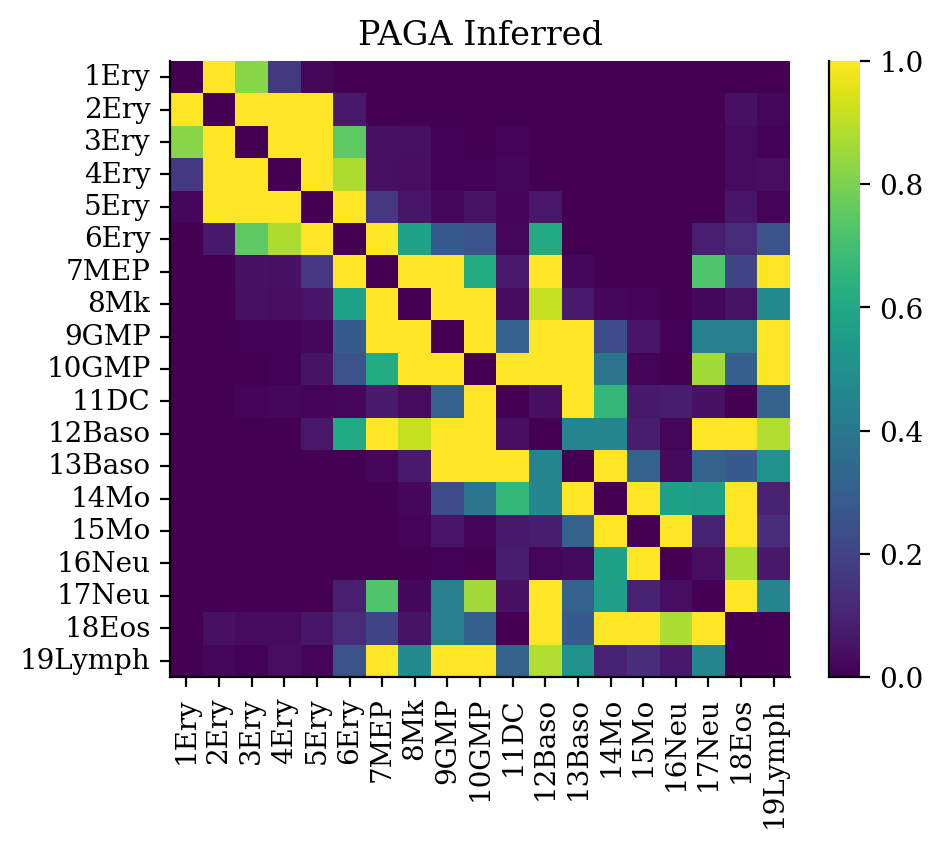

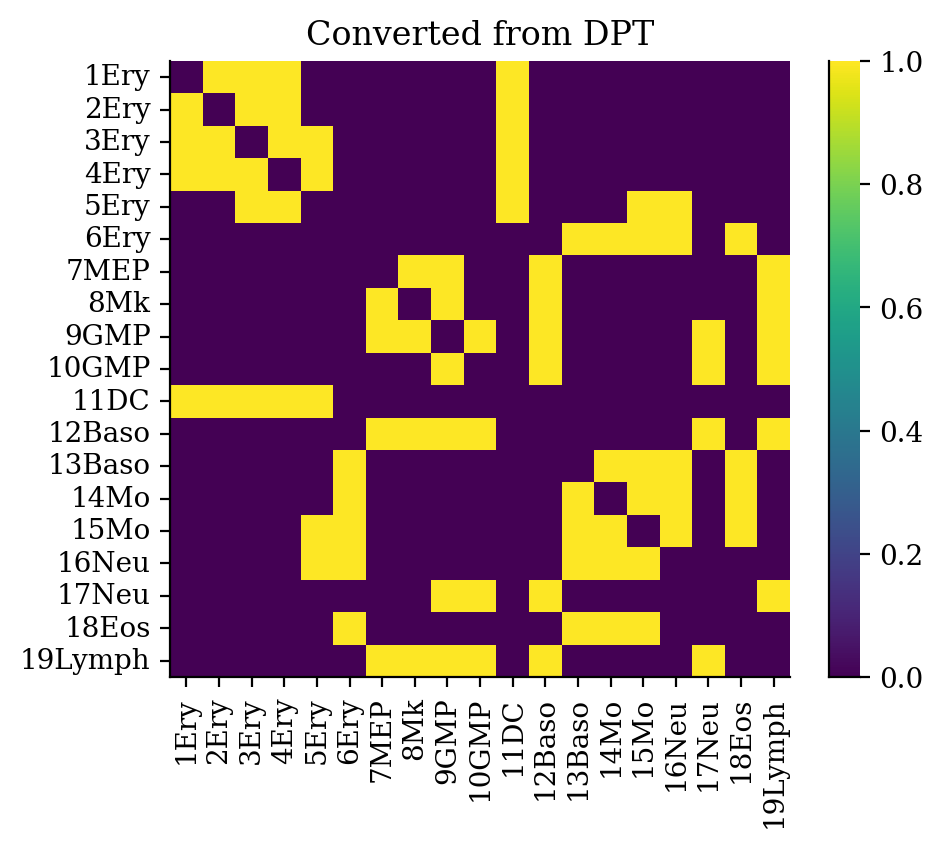

In [105]:
plt.figure(figsize=(5, 4))
sns.heatmap(adjacency_matrix_df, cmap='viridis')
sns.despine()
plt.title("PAGA Inferred")
plt.show()

adjacency_matrix_converted = converter.get_label_adjacency(method="knn", adjacency_kwargs=dict(n_neighbors=5))
adjacency_matrix_df_converted = pd.DataFrame(adjacency_matrix_converted, columns=adjacency_matrix_labels, index=adjacency_matrix_labels)
plt.figure(figsize=(5, 4))
sns.heatmap(adjacency_matrix_df_converted, cmap='viridis')
sns.despine()
plt.title("Converted from DPT")
plt.show()